In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.dummy import DummyRegressor

import warnings
warnings.filterwarnings('ignore')

SEED = 123
np.random.seed(SEED)

In [5]:
df = pd.read_parquet('puzzles_features.parquet')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (1000000, 90)


,Rating,RatingDeviation,Popularity,NbPlays,num_moves,num_openings,num_themes,has_mate,total_material,material_balance,...,masterVsMaster,hookMate,castling,doubleBishopMate,short,crushing,equality,kingsideAttack,sacrifice,backRankMate
0,1344,76,90,1728,4,2,5,False,7000,0,...,0,0,0,0,1,1,0,0,0,0
1,1526,76,96,22662,6,0,5,False,1400,0,...,0,0,0,0,0,1,0,0,0,0
2,2213,75,97,1240,6,0,5,False,1100,100,...,0,0,0,0,0,1,0,0,0,0


In [6]:
X = df.drop(columns=['Popularity'])
y = df['Popularity'].astype(float)

print(f'Features: {X.shape[1]}')
print(f'Samples:  {X.shape[0]}')

Features: 89
Samples:  1000000


In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=SEED)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED)

print(f'Full train : {len(X_train):,}')
print(f'Val        : {len(X_val):,}')
print(f'Test       : {len(X_test):,}')

Full train : 800,000
Val        : 100,000
Test       : 100,000


In [8]:
# we need to standardize the features to avoid data leakage

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print('Scaling complete.')
print(f'Mean of first feature (train): {X_train_scaled[:, 0].mean():.4f}')
print(f'Std  of first feature (train): {X_train_scaled[:, 0].std():.4f}')

Scaling complete.
Mean of first feature (train): 0.0000
Std  of first feature (train): 1.0000


In [9]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_scaled, y_train)
dummy_preds = dummy.predict(X_test_scaled)

dummy_rmse = np.sqrt(mean_squared_error(y_test, dummy_preds))
dummy_mae  = mean_absolute_error(y_test, dummy_preds)
dummy_r2   = r2_score(y_test, dummy_preds)

print(f'Dummy (predict mean)  RMSE={dummy_rmse:.4f}  MAE={dummy_mae:.4f}  R²={dummy_r2:.4f}')

Dummy (predict mean)  RMSE=14.2127  MAE=9.2106  R²=-0.0000


## Training

Architecture: 3 hidden layers (256 → 128 → 64 neurons) with ReLU activations. Early stopping monitors validation loss to prevent overfitting and saves training time.

In [10]:
mlp = MLPRegressor(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=100,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=SEED,
    verbose=True
)

mlp.fit(X_train_scaled, y_train)
print(f'\nStopped at epoch: {mlp.n_iter_}')

Iteration 1, loss = 99.20696295
Validation score: 0.347365
Iteration 2, loss = 64.75575919
Validation score: 0.374710
Iteration 3, loss = 62.99056292
Validation score: 0.359911
Iteration 4, loss = 62.11603792
Validation score: 0.381096
Iteration 5, loss = 61.46624237
Validation score: 0.389607
Iteration 6, loss = 61.01954959
Validation score: 0.380012
Iteration 7, loss = 60.66404614
Validation score: 0.394399
Iteration 8, loss = 60.39708590
Validation score: 0.392710
Iteration 9, loss = 60.10796848
Validation score: 0.376079
Iteration 10, loss = 59.86057476
Validation score: 0.392980
Iteration 11, loss = 59.64061637
Validation score: 0.397879
Iteration 12, loss = 59.38365942
Validation score: 0.395262
Iteration 13, loss = 59.11366901
Validation score: 0.404929
Iteration 14, loss = 59.00202353
Validation score: 0.397967
Iteration 15, loss = 58.76341278
Validation score: 0.399380
Iteration 16, loss = 58.58119838
Validation score: 0.389339
Iteration 17, loss = 58.39413759
Validation score

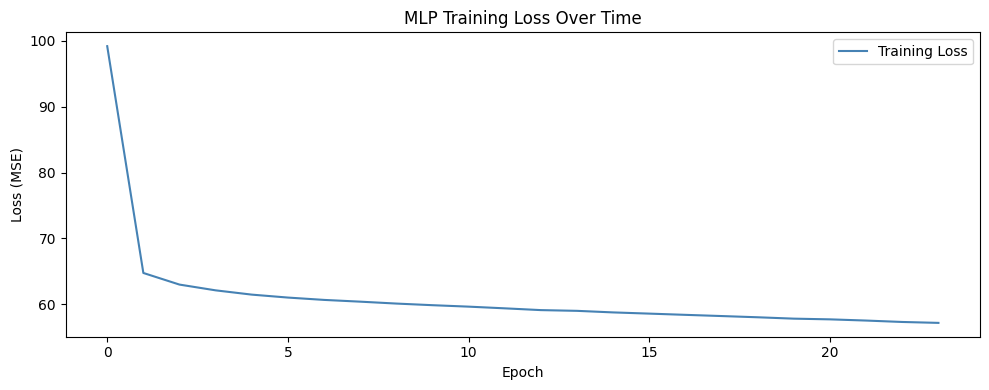

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(mlp.loss_curve_, color='steelblue', label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('MLP Training Loss Over Time')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
y_val_pred  = mlp.predict(X_val_scaled)
y_test_pred = mlp.predict(X_test_scaled)

val_mae  = mean_absolute_error(y_val, y_val_pred)
val_rmse  = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_r2    = r2_score(y_val, y_val_pred)
test_mae  = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2   = r2_score(y_test, y_test_pred)

print(f'{"":25s}  {"RMSE":>8s}  {"MAE":>8s}  {"R²":>8s}')
print(f'{"Validation":25s}  {val_rmse:>8.4f}  {val_mae:>8.4f}  {val_r2:>8.4f}')
print(f'{"Test":25s}  {test_rmse:>8.4f}  {test_mae:>8.4f}  {test_r2:>8.4f}')

                               RMSE       MAE        R²
Validation                  10.9353    6.7358    0.4071
Test                        10.8728    6.7104    0.4148


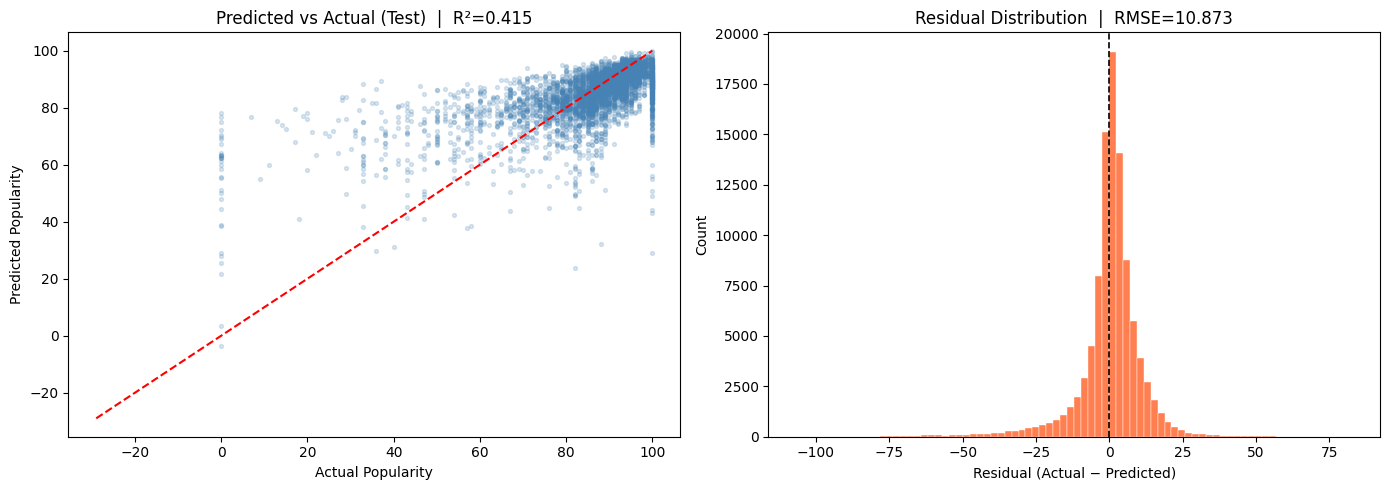

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sample_idx = np.random.choice(len(y_test), size=5000, replace=False)
axes[0].scatter(y_test.iloc[sample_idx], y_test_pred[sample_idx], alpha=0.2, s=8, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual Popularity')
axes[0].set_ylabel('Predicted Popularity')
axes[0].set_title(f'Predicted vs Actual (Test)  |  R²={test_r2:.3f}')

residuals = y_test.values - y_test_pred
axes[1].hist(residuals, bins=80, color='coral', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution  |  RMSE={test_rmse:.3f}')

plt.tight_layout()
plt.show()